In [2]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

In [4]:
model = MobileNetV2(weights='imagenet')

model.input_shape

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


(None, 224, 224, 3)

In [10]:
model.output_shape

(None, 1000)

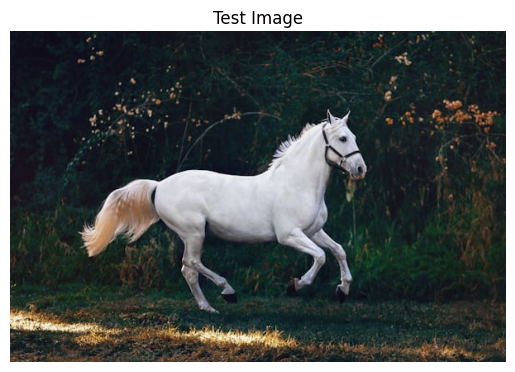

In [35]:
url = "https://images.unsplash.com/photo-1553284965-83fd3e82fa5a?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8aG9yc2V8ZW58MHx8MHx8fDA%3D"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    img = Image.open(BytesIO(response.content))
    
    plt.imshow(img)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()
else:
    print(f"Failed to download. Error code: {response.status_code}")

In [36]:
def preprocess_image(img):
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

processed = preprocess_image(img)
print("Processed shape:", processed.shape)


Processed shape: (1, 224, 224, 3)


In [37]:
predictions = model.predict(processed)
print("Predictions shape:", predictions.shape)

results = decode_predictions(predictions, top=5)[0]
print("\nTop 5 predictions:")
for rank, (id, label, confidence) in enumerate(results):
    print(f"{rank+1}. {label}: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Predictions shape: (1, 1000)

Top 5 predictions:
1. Saluki: 56.47%
2. whippet: 3.41%
3. Great_Dane: 2.75%
4. kuvasz: 2.51%
5. white_wolf: 1.94%
